### Adding PD noise trace to gwinc

In [ ]:
import copy
import numpy as np
import scipy.constants as sc
import gwinc
from gwinc import nb, Struct
from gwinc.noise.quantum import precomp_quantum, Readout as ReadoutVacuum
import matplotlib.pyplot as plt
import os

class PDReadoutNoise(nb.Noise):
    """Photodiode dark current + readout electronics, referred to strain.
    
    Dark noise contributions and shot noise are both white current noises injected at the photodiode, so they share the optical-to-strain transfer function and their current-PSD ratio rho transfers directly.  
    The shot reference is gwinc's own readout-loss vacuum term, Quantum.Readout / (1 - eta).
    
    Balanced homodyne: N = 2 diodes, LO split 50/50, signals summed
    coherently, dark sides uncorrelated.  Returns DISPLACEMENT psd.
    """
    style = dict(label=r'PD dark + electronics', color='xkcd:brown', linestyle='-')

    @nb.precomp(quantum=precomp_quantum)
    def calc(self, quantum):
        ifo, f = self.ifo, self.freq
        pd, eta = ifo.Optics.Readout, ifo.Optics.PhotoDetectorEfficiency

        # photocurrent
        R = (pd.Responsivity if 'Responsivity' in pd
             else eta * sc.e * ifo.Laser.Wavelength / (sc.h * sc.c))
        I_dc = pd.Photocurrent if 'Photocurrent' in pd else R * pd.LOPower
        N    = pd.get('NDiodes', 2)

        # dark-side current-noise PSD per diode [A²/Hz]
        I_dk = pd.get('DarkCurrent', 0.0)
        T    = pd.get('Temperature', 298.0)

        S_shot_dark = 2 * sc.e * I_dk
        S_johnson   = 4 * sc.k * T / pd.Rshunt if pd.get('Rshunt') else 0.0

        # electronics: prefer NoiseEquivalentPhotocurrent, else CurrentNoise
        if 'NoiseEquivalentPhotocurrent' in pd:
            I_eq = pd.NoiseEquivalentPhotocurrent
            i_n2 = 2 * sc.e * I_eq
        else:
            i_n  = pd.get('CurrentNoise', 0.0)
            i_n2 = i_n**2

        # 1/f amplifier noise
        fc = pd.get('AmpCorner', 0.0)
        be = pd.get('AmpExponent', 1.0)
        S_amp = i_n2 * (1 + (fc / f)**be if fc > 0 else 1.0)

        # Hooge / flicker (classic form)
        aH = pd.get('HoogeAlpha', 0.0)
        bH = pd.get('HoogeExponent', 2.0)
        I_pd = I_dc / N
        S_hooge = aH * (I_pd + I_dk)**bH / f if aH > 0 else 0.0

        S_i = S_shot_dark + S_johnson + S_amp + S_hooge
        rho = N * S_i / (2 * sc.e * I_dc)

        self.rho = float(rho) if np.isscalar(rho) else float(rho[np.argmin(np.abs(f - 1000))])
        self.rho_f = rho if not np.isscalar(rho) else rho * np.ones_like(f)

        # convert to strain using the ordinary shot-noise reference
        lam = 1 - eta
        if lam >= 1e-4:
            shot = quantum.PD / lam
        else:
            p = copy.deepcopy(ifo)
            lam = 1e-3
            p.Optics.PhotoDetectorEfficiency = 1 - lam
            shot = ReadoutVacuum(freq=f, ifo=p)._calc(dict()) / lam

        return self.rho_f * shot


def budget_with_pd(name, freq, eta, **pd):
    """Return a budget that includes PDReadoutNoise."""
    b0 = gwinc.load_budget(name, freq=freq)
    b0.ifo.Optics.PhotoDetectorEfficiency = float(eta)
    b0.ifo.Optics.Readout = Struct(**pd)
    cls = type(name + 'PD', (type(b0),),
               dict(noises=list(type(b0).noises) + [PDReadoutNoise]))
    return cls(freq=freq, ifo=b0.ifo)

Considering just a white floor to start

rho(1 kHz) = 5.001e-04   (33.0 dB below shot)
Grote SNR  = 45
S_loss     = 0.0250 %
V_loss     = 0.0750 %


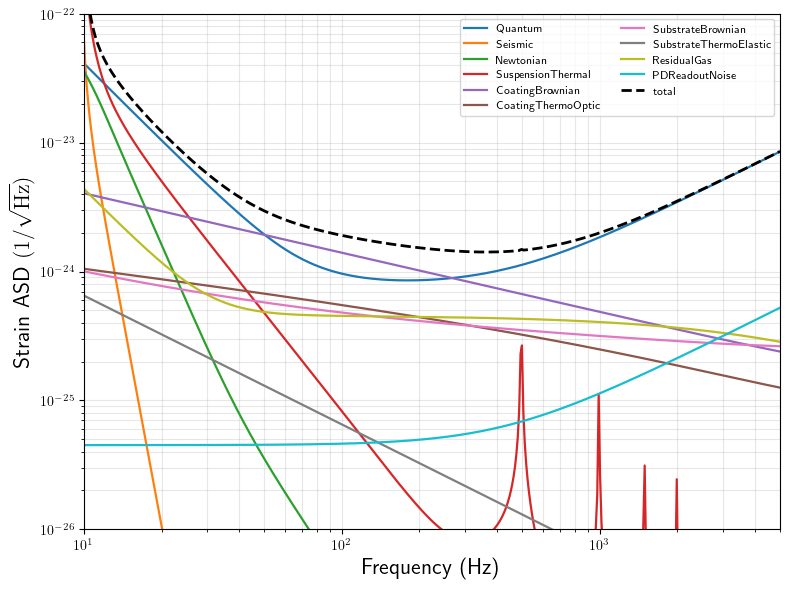

In [ ]:
# ------------------------------------------------------------------
#  Parameters
# ------------------------------------------------------------------
I_EQ_GROTE = 5e-6          # A   noise-equivalent photocurrent (Grote 2016)
I_DARK     = 800e-12       # A   IGHQEX0500 datasheet
I_DC       = 20e-3         # A   total photocurrent
N_DIODES   = 2
ETA        = 0.995         # quantum efficiency

freq = np.logspace(np.log10(10), np.log10(5000), 500)

# build the budget
b = budget_with_pd(
    'Aplus', freq, ETA,
    Photocurrent                 = I_DC,
    NDiodes                      = N_DIODES,
    NoiseEquivalentPhotocurrent  = I_EQ_GROTE,
    DarkCurrent                  = I_DARK,
    # Leave them out (or set to 0) for a pure white floor
    # AmpCorner                 = 0.0,
    # HoogeAlpha                = 0.0,
)

t   = b.run()
obj = b._noise_objs['PDReadoutNoise']

# diagnostics
print(f'rho(1 kHz) = {obj.rho:.3e}   ({-10*np.log10(obj.rho):.1f} dB below shot)')
print(f'Grote SNR  = {1/np.sqrt(obj.rho):.0f}')
print(f'S_loss     = {100*((1+obj.rho)**0.5 - 1):.4f} %')
print(f'V_loss     = {100*((1+obj.rho)**1.5 - 1):.4f} %')

# plot
fig, ax = plt.subplots(figsize=(8, 6))
for k in t.keys():
    ax.loglog(freq, t[k].asd, lw=1.6, label=k)
ax.loglog(freq, t.asd, 'k--', lw=2, label='total')
ax.set_xlim(10, 5000)
ax.set_ylim(1e-26, 1e-22)
ax.set_xlabel(r'Frequency (Hz)', fontsize=16)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=16)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
# fig.savefig(os.path.join(fig_dir, 'Aplus_with_PD_readout_noise.png'), dpi=300)
plt.show()

fixed cosmetics

I_pd        = 25.0 mA per diode
S_i         = 1.6024e-24 A^2/Hz  =  1.2659 pA/rtHz
shot ref    = 126.58 pA/rtHz
rho(1 kHz)  = 2.0003e-04   (36.99 dB below shot)
sqrt(rho)   = 1.41 %
SNR         = 70.7
S_loss      = 0.0100 %
V_loss      = 0.0300 %   (shot-limited)
I_dark share of S_i = 0.016 %


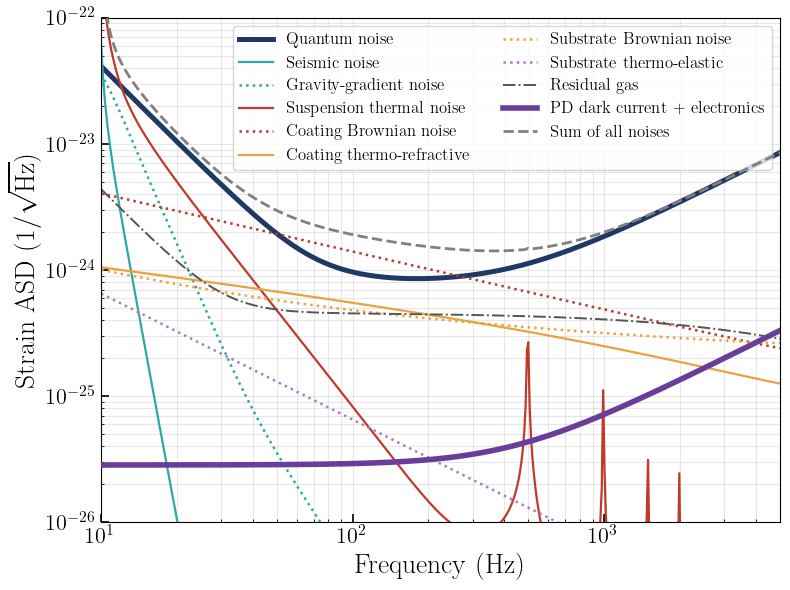

Saved: /Users/asca/PhD/photodiodes/code/gwinc/fig/Aplus_with_PD_readout_noise.png
unstyled keys: none


In [ ]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
 
path = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)
 
# ---------------------------------------------------------------------------
#  Parameters
#
#  I_DC: 50 mA total is the figure quoted for CURRENT LIGO (DC readout, two
#  summed DCPDs).  Whether A+ BHD runs at the same total has NOT been
#  verified (check alog, white papers).
#
#  NOTE 25 mA per diode exceeds the 10 mA maximum forward current on the
#  Laser Components HQE datasheet.  The devices in LIGO are from a dedicated
#  2006 production run, not the catalogue parts, so the 800 pA dark current
#  below is a catalogue number standing in for an unmeasured one.
# ---------------------------------------------------------------------------
I_EQ_GROTE = 5e-6          # A   noise-equivalent photocurrent (Grote 2016, >1 kHz)
I_DARK     = 800e-12       # A   IGHQEX0500 datasheet, at -2.5 V
I_DC       = 50e-3         # A   total photocurrent  (was 20e-3)
N_DIODES   = 2
ETA        = 0.995         # gwinc
 
freq = np.logspace(np.log10(10), np.log10(5000), 500)
 
b = budget_with_pd(
    'Aplus', freq, ETA,
    Photocurrent                = I_DC,
    NDiodes                     = N_DIODES,
    NoiseEquivalentPhotocurrent = I_EQ_GROTE,
    DarkCurrent                 = I_DARK,
    # AmpCorner  = 0.0,     # leave out for a pure white floor
    # HoogeAlpha = 0.0,
)
 
t   = b.run()
obj = b._noise_objs['PDReadoutNoise']
 
S_i  = 2 * sc.e * (I_DARK + I_EQ_GROTE)
I_pd = I_DC / N_DIODES
print(f'I_pd        = {I_pd*1e3:.1f} mA per diode')
print(f'S_i         = {S_i:.4e} A^2/Hz  =  {np.sqrt(S_i)*1e12:.4f} pA/rtHz')
print(f'shot ref    = {np.sqrt(2*sc.e*I_DC)*1e12:.2f} pA/rtHz')
print(f'rho(1 kHz)  = {obj.rho:.4e}   ({-10*np.log10(obj.rho):.2f} dB below shot)')
print(f'sqrt(rho)   = {100*np.sqrt(obj.rho):.2f} %')
print(f'SNR         = {1/np.sqrt(obj.rho):.1f}')
print(f'S_loss      = {100*((1+obj.rho)**0.5 - 1):.4f} %')
print(f'V_loss      = {100*((1+obj.rho)**1.5 - 1):.4f} %   (shot-limited)')
print(f'I_dark share of S_i = {100*I_DARK/(I_DARK+I_EQ_GROTE):.3f} %')
 
PD_KEY = 'PDReadoutNoise'
 
noise_style = {
    'Quantum':                dict(label=r'Quantum noise',              color='#1f3864', ls='-',  lw=3.6),
    'Seismic':                dict(label=r'Seismic noise',              color='#2ca9a3', ls='-',  lw=1.6),
    'Newtonian':              dict(label=r'Gravity-gradient noise',     color='#2ca9a3', ls=':',  lw=1.8),
    'SuspensionThermal':      dict(label=r'Suspension thermal noise',   color='#c0392b', ls='-',  lw=1.6),
    'CoatingBrownian':        dict(label=r'Coating Brownian noise',     color='#c0392b', ls=':',  lw=1.8),
    'CoatingThermoOptic':     dict(label=r'Coating thermo-refractive',  color='#e8a33d', ls='-',  lw=1.6),
    'SubstrateBrownian':      dict(label=r'Substrate Brownian noise',   color='#e8a33d', ls=':',  lw=1.8),
    'SubstrateThermoElastic': dict(label=r'Substrate thermo-elastic',   color='#af7ac5', ls=':',  lw=1.8),
    'ITMThermoRefractive':    dict(label=r'ITM thermo-refractive',      color='#af7ac5', ls='-',  lw=1.6),
    'ResidualGas':            dict(label=r'Residual gas',               color='#555555', ls='-.', lw=1.4),
    'ExcessGas':              dict(label=r'Residual gas',               color='#555555', ls='-.', lw=1.4),
    PD_KEY:                   dict(label=r'PD dark current $+$ electronics',
                                   color='#6a3d9a', ls='-',  lw=4.0),
}
 
def texsafe(s):
    """Escape a raw gwinc key so usetex does not choke on it."""
    return s.replace('_', r'\_').replace('%', r'\%').replace('&', r'\&')
 
 
fig, ax = plt.subplots(figsize=(8, 6))
 
keys = list(t.keys())
ordered  = [k for k in noise_style if k in keys and k != PD_KEY]
ordered += [k for k in keys if k not in noise_style and k != PD_KEY]
 
for k in ordered:
    s = noise_style.get(k, dict(label=texsafe(k), color='0.3', ls='-', lw=1.2))
    ax.loglog(freq, t[k].asd, label=s['label'], color=s['color'],
              ls=s['ls'], lw=s['lw'], zorder=2)
 
if PD_KEY in keys:                                   # thick, on top
    s = noise_style[PD_KEY]
    ax.loglog(freq, t[PD_KEY].asd, label=s['label'], color=s['color'],
              ls=s['ls'], lw=s['lw'], zorder=5)
 
ax.loglog(freq, t.asd, label=r'Sum of all noises', color='gray',
          ls='--', lw=2.0, zorder=6)
 
ax.set_xlabel(r'Frequency (Hz)', fontsize=20)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_xlim(10, 5000)
ax.set_ylim(1e-26, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2,
               direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right', fontsize=12, frameon=True, ncol=2)
 
fig.tight_layout()
save_path = os.path.join(fig_dir, "Aplus_with_PD_readout_noise.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#fig.savefig(os.path.join(fig_dir, "Aplus_with_PD_readout_noise.svg"), bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {save_path}")
 
unstyled = [k for k in keys if k not in noise_style]
print('unstyled keys:', unstyled or 'none')